In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ==============================
# 1 โหลดข้อมูลทอง
# ==============================

symbol = "GC=F"

data = yf.download(
    symbol,
    period="60d", # Use period='60d' to get recent 5m data
    interval="5m"
)

data = data.dropna()

# Flatten MultiIndex columns if they exist (common with yfinance for single tickers)
# This assumes the actual metric name is in the first level and ticker symbol in the second
if isinstance(data.columns, pd.MultiIndex):
    # If the first level contains attribute names (Close, High, etc.) and second is ticker
    if 'Close' in data.columns.get_level_values(0):
        data.columns = data.columns.get_level_values(0)
    # If the first level is ticker and second is attribute names
    elif symbol in data.columns.get_level_values(0):
        data.columns = data.columns.get_level_values(1)

[*********************100%***********************]  1 of 1 completed


# ATR

In [2]:
# ==============================
# 3 คำนวณ ATR
# ==============================

data["H-L"] = data["High"] - data["Low"]
data["H-C"] = abs(data["High"] - data["Close"].shift())
data["L-C"] = abs(data["Low"] - data["Close"].shift())

data["TR"] = data[["H-L","H-C","L-C"]].max(axis=1)

data["ATR"] = data["TR"].rolling(14).mean()

# Breakout Levels

In [3]:
# ==============================
# Breakout Levels
# ==============================

lookback = 50

data["HH"] = data["High"].rolling(lookback).max()
data["LL"] = data["Low"].rolling(lookback).min()

# Signal

In [4]:
# ==============================
# Signals
# ==============================

data["signal"] = 0

for i in range(lookback, len(data)):

    close = data["Close"].iloc[i]
    atr = data["ATR"].iloc[i]

    upper = data["HH"].iloc[i-1] + atr * 2
    lower = data["LL"].iloc[i-1] - atr * 2

    if close > upper:
        data.iloc[i, data.columns.get_loc("signal")] = 1

    elif close < lower:
        data.iloc[i, data.columns.get_loc("signal")] = -1

In [5]:
lookbacks = [10,20,30,40,50]
atr_multipliers = [0.5,1,1.5,2,3]
rr_values = [1.5,2,3]

results = []

for lookback in lookbacks:

    data["HH"] = data["High"].rolling(lookback).max()
    data["LL"] = data["Low"].rolling(lookback).min()

    for atr_mult in atr_multipliers:

        for rr in rr_values:

            balance = 200
            trades = []

            for i in range(lookback, len(data)):

                close = data["Close"].iloc[i]
                atr = data["ATR"].iloc[i]

                upper = data["HH"].iloc[i-1] + atr * atr_mult
                lower = data["LL"].iloc[i-1] - atr * atr_mult

                # BUY
                if close > upper:

                    entry = close
                    sl = entry - atr
                    tp = entry + atr * rr

                    for j in range(i+1, min(i+30,len(data))):

                        if data["Low"].iloc[j] <= sl:
                            trades.append(-1)
                            balance *= 0.99
                            break

                        if data["High"].iloc[j] >= tp:
                            trades.append(1)
                            balance *= 1.01
                            break

                # SELL
                elif close < lower:

                    entry = close
                    sl = entry + atr
                    tp = entry - atr * rr

                    for j in range(i+1, min(i+30,len(data))):

                        if data["High"].iloc[j] >= sl:
                            trades.append(-1)
                            balance *= 0.99
                            break

                        if data["Low"].iloc[j] <= tp:
                            trades.append(1)
                            balance *= 1.01
                            break

            if len(trades) > 0:

                trades = np.array(trades)

                winrate = np.sum(trades==1) / len(trades)

                results.append({
                    "lookback":lookback,
                    "ATR_mult":atr_mult,
                    "RR":rr,
                    "trades":len(trades),
                    "winrate":winrate,
                    "balance":balance
                })

results_df = pd.DataFrame(results)

results_df.sort_values("balance",ascending=False).head(10)

,lookback,ATR_mult,RR,trades,winrate,balance
69,50,2.0,1.5,29,0.655172,218.518416
54,40,2.0,1.5,33,0.575758,209.907918
39,30,2.0,1.5,35,0.571429,209.886928
57,40,3.0,1.5,12,0.666667,208.037566
24,20,2.0,1.5,38,0.552632,207.767280
72,50,3.0,1.5,11,0.636364,205.977788
27,20,3.0,1.5,13,0.615385,205.957191
42,30,3.0,1.5,13,0.615385,205.957191
9,10,2.0,1.5,43,0.534884,205.648471
58,40,3.0,2.0,12,0.583333,203.918010


In [6]:
# ==============================
# Backtest
# ==============================

balance = 50
initial_balance = balance
risk_per_trade = 0.2

equity = []
trades = []

for i in range(len(data)):

    if data["signal"].iloc[i] == 1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry - atr * 1
        tp = entry + atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):

            if data["Low"].iloc[j] <= sl:
                result = -1
                break

            if data["High"].iloc[j] >= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)

    elif data["signal"].iloc[i] == -1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry + atr * 1
        tp = entry - atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):

            if data["High"].iloc[j] >= sl:
                result = -1
                break

            if data["Low"].iloc[j] <= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)

    equity.append(balance)

Total Trades: 29
Wins: 19
Losses: 10
Winrate: 65.52 %
Initial Balance 50
Final Balance: 171.52


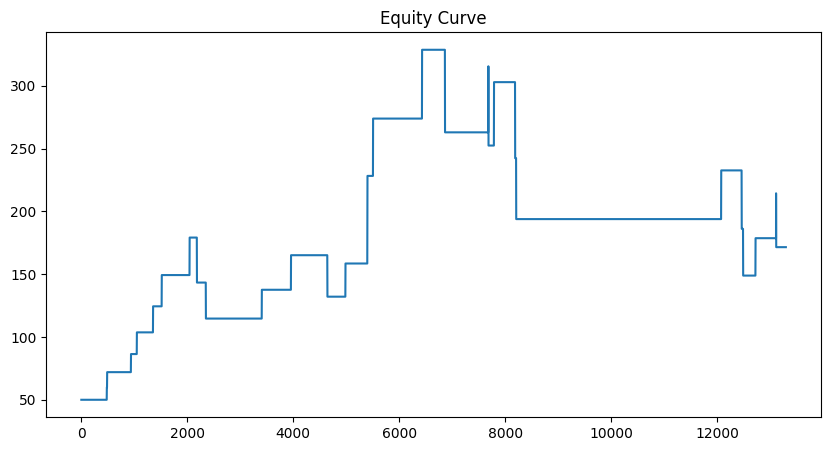

In [12]:
# ==============================
# Results
# ==============================

trades = np.array(trades)

total = len(trades)
wins = np.sum(trades == 1)
losses = np.sum(trades == -1)

winrate = wins / total if total > 0 else 0

print("Total Trades:", total)
print("Wins:", wins)
print("Losses:", losses)
print("Winrate:", round(winrate*100,2), "%")
print("="*20)
print("Initial Balance", initial_balance)
print("Final Balance:", round(balance,2))

# ==============================
# Equity Curve
# ==============================

plt.figure(figsize=(10,5))
plt.plot(equity)
plt.title("Equity Curve")
plt.show()

In [13]:
# ==============================
# Backtest
# ==============================

balance = 50
initial_balance = balance
risk_per_trade = 0.2

equity = []
trades = []

# เพิ่ม List สำหรับเก็บข้อมูลไปทำ ML
trade_records = [] 

for i in range(len(data)):

    if data["signal"].iloc[i] == 1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry - atr * 1
        tp = entry + atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):

            if data["Low"].iloc[j] <= sl:
                result = -1
                break

            if data["High"].iloc[j] >= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)
            
            # --------- ส่วนที่จัดเตรียมข้อมูลให้เพื่อนทำ ML ---------
            entry_time = data.index[i]
            hour = entry_time.hour
            
            # จัดกลุ่ม Session คร่าวๆ อิงตามเวลา New York (ยึดตาม Timezone ของ yfinance/GC=F)
            if 8 <= hour < 16:
                session = 'NY'
            elif 3 <= hour < 8:
                session = 'London'
            else:
                session = 'Asia'

            # บันทึกเฉพาะสิ่งที่สำคัญจริงๆ (ตัด OHLC และตัวแปรดิบทิ้ง)
            ml_data = {
                'Entry_Time': entry_time,
                'Hour_of_Day': hour,
                'Day_of_Week': entry_time.dayofweek, # วันจันทร์=0, อาทิตย์=6
                'Session': session,
                'ATR': atr,
                'signal': 1,              # ซื้อ (Buy)
                'Trade_Type': 'Buy',
                'Label': 'TP' if result == 1 else 'SL'
            }
            trade_records.append(ml_data)
            # --------------------------------------------------------

    elif data["signal"].iloc[i] == -1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry + atr * 1
        tp = entry - atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):

            if data["High"].iloc[j] >= sl:
                result = -1
                break

            if data["Low"].iloc[j] <= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)
            
            # --------- ส่วนที่จัดเตรียมข้อมูลให้เพื่อนทำ ML ---------
            entry_time = data.index[i]
            hour = entry_time.hour
            
            # จัดกลุ่ม Session คร่าวๆ
            if 8 <= hour < 16:
                session = 'NY'
            elif 3 <= hour < 8:
                session = 'London'
            else:
                session = 'Asia'

            # บันทึกเฉพาะสิ่งที่สำคัญจริงๆ
            ml_data = {
                'Entry_Time': entry_time,
                'Hour_of_Day': hour,
                'Day_of_Week': entry_time.dayofweek,
                'Session': session,
                'ATR': atr,
                'signal': -1,             # ขาย (Sell)
                'Trade_Type': 'Sell',
                'Label': 'TP' if result == 1 else 'SL'
            }
            trade_records.append(ml_data)
            # --------------------------------------------------------

    equity.append(balance)


# ==============================
# สร้าง DataFrame พิเศษสำหรับส่งให้เพื่อนทำตาราง ML โมเดล
# ==============================
df_ml = pd.DataFrame(trade_records)

# ตรวจสอบหน้าตาข้อมูล
print("ข้อมูล ML แบบ Clean แล้วพร้อมส่งให้เพื่อน, จำนวน Trade:", df_ml.shape[0])
display(df_ml.head())

# บันทึกเป็นไฟล์ CSV
df_ml.to_csv("clean_backtest_data_for_ml.csv", index=False)
print("👉 บันทึกไฟล์ 'clean_backtest_data_for_ml.csv' เรียบร้อยแล้ว โยนให้เพื่อนได้เลย!")


ข้อมูล ML แบบ Clean แล้วพร้อมส่งให้เพื่อน, จำนวน Trade: 29


,Entry_Time,Hour_of_Day,Day_of_Week,Session,ATR,signal,Trade_Type,Label
0,2026-01-19 04:30:00+00:00,4,0,London,8.749965,1,Buy,TP
1,2026-01-20 05:00:00+00:00,5,1,London,9.671352,1,Buy,TP
2,2026-01-21 19:35:00+00:00,19,2,Asia,12.207136,-1,Sell,TP
3,2026-01-22 05:50:00+00:00,5,3,London,4.650042,1,Buy,TP
4,2026-01-23 08:20:00+00:00,8,4,NY,6.642927,-1,Sell,TP


👉 บันทึกไฟล์ 'clean_backtest_data_for_ml.csv' เรียบร้อยแล้ว โยนให้เพื่อนได้เลย!


จำนวนข้อมูลนำมา Train Model:  23
ความแม่นยำในการทำนาย (Accuracy): 66.67 %

--- ผลสรุปการทำนายบนชุด Test (ข้อสอบย่อย) ---
              precision    recall  f1-score   support

      SL (0)       0.50      1.00      0.67         2
      TP (1)       1.00      0.50      0.67         4

    accuracy                           0.67         6
   macro avg       0.75      0.75      0.67         6
weighted avg       0.83      0.67      0.67         6



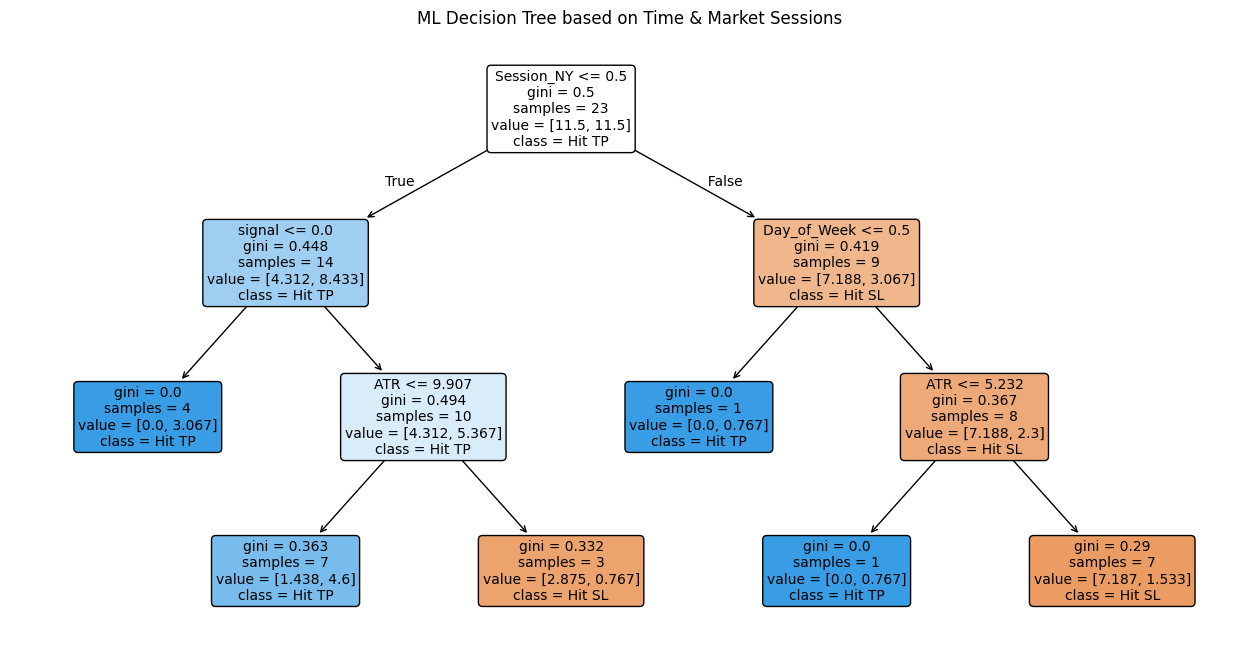


--- สัดส่วนความสำคัญของแต่ละตัวแปร (Feature Importances) ---


,Feature,Importance
2,ATR,0.419733
6,Session_NY,0.268179
3,signal,0.165949
1,Day_of_Week,0.146139
0,Hour_of_Day,0.000000
4,Session_Asia,0.000000
5,Session_London,0.000000
7,Trade_Type_Buy,0.000000
8,Trade_Type_Sell,0.000000


In [15]:
# ==============================
# สร้าง ML: Decision Tree เพื่อคัดกรองไม้เข้า
# ==============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

# 1. เตรียมข้อมูลจากตาราง 
# (เพื่อนสามารถเปลี่ยนคำสั่งนี้เป็น pd.read_csv("clean_backtest_data_for_ml.csv") ตอนโยนไฟล์ไปได้เลย)
df_clean = df_ml.copy()

# แปลงเป้าหมาย (Label) : รอด (TP) จะเท่ากับ 1 หรือ เจ๊ง (SL) จะเท่ากับ 0 
df_clean['Target'] = df_clean['Label'].apply(lambda x: 1 if x == 'TP' else 0)

# ทำ One-Hot Encoding ให้กับตัวหนังสือ (Session และ Trade_Type) ให้กลายเป็น 1 กับ 0 
# เช่น มีคอลัมน์ชื่อ Session_NY ถ้าใช่มันจะเป็น 1 ไม่ใช่จะเป็น 0
df_clean = pd.get_dummies(df_clean, columns=['Session', 'Trade_Type'])

# ลิสต์รายชื่อคอลัมน์ที่โมเดลจะใช้เป็น X (Features) แบบเน้นๆ (เหลือแต่เวลา ความผันผวน และช่วงตลาด)
features = [
    'Hour_of_Day', 
    'Day_of_Week', 
    'ATR', 
    'signal'
] 
# สมทบคอลัมน์ One-Hot ที่สร้างใหม่ทั้งหมดเข้าไป (Session กับ Trade Type)
features += [col for col in df_clean.columns if col.startswith('Session_')]
features += [col for col in df_clean.columns if col.startswith('Trade_Type_')]

# แยกตัวหนังสือเป็น X (เกณฑ์ตัดสิน) ยละ y (เฉลยที่ AI ต้องเรียน)
X = df_clean[features]
y = df_clean['Target']

# 2. แบ่งข้อมูลเอาไว้สำหรับ สอน (Train) 80% และ ทดสอบความแม่น (Test) 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. สร้างแผนผังและสอนให้ Decision Tree เรียนจากข้อมูล
# max_depth=3 คือไม่ให้ AI ไปจำซับซ้อนเกินไป (กันจำข้อสอบ)
model = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. ทดสอบโมเดลโดยลองเดาบนชุด Test 
y_pred = model.predict(X_test)

print("จำนวนข้อมูลนำมา Train Model: ", X_train.shape[0])
print("ความแม่นยำในการทำนาย (Accuracy):", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\n--- ผลสรุปการทำนายบนชุด Test (ข้อสอบย่อย) ---")
print(classification_report(y_test, y_pred, target_names=['SL (0)', 'TP (1)']))

# 5. วาดแผนผังกระบวนการคิดของ AI 
plt.figure(figsize=(16, 8))
tree.plot_tree(
    model, 
    feature_names=features, 
    class_names=['Hit SL', 'Hit TP'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("ML Decision Tree based on Time & Market Sessions")
plt.show()

# 6. (Bonus) เรียงลำดับโชว์ว่า AI บอกว่าฟีเจอร์ไหนสำคัญสุดเวลาเทรด
importance_df = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
print("\n--- สัดส่วนความสำคัญของแต่ละตัวแปร (Feature Importances) ---")
display(importance_df.sort_values(by='Importance', ascending=False))
